## 9. Feature Engineering

Tất cả lag/rolling/diff **tính từ `pm25_raw`** (giá trị gốc µg/m³, chưa scale).

> **Lý do chống leakage:** Nếu tính lag từ pm25 đã scale, các giá trị lag sẽ encode phân phối toàn bộ dataset → data leakage từ Val/Test vào Train.


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.features import create_features
from src.evaluation import calculate_metrics, predict_and_inverse
df_train = pd.read_csv('../data/train_clean.csv')
df_val   = pd.read_csv('../data/val_clean.csv')
df_test  = pd.read_csv('../data/test_clean.csv')

print("Tạo features cho từng tập...")
df_train = create_features(df_train)
df_val   = create_features(df_val)
df_test  = create_features(df_test)
print("Train/Val/Test: Done")

lag_cols   = [c for c in df_train.columns if any(k in c for k in ['lag_','roll_','_diff_'])]
check_cols = lag_cols + ['pm25']

print(f"\nSố dòng trước khi drop NaN (do lag/rolling):")
print(f"Train={len(df_train):,} | Val={len(df_val):,} | Test={len(df_test):,}")

df_train.dropna(subset=check_cols, inplace=True)
df_val.dropna(subset=check_cols,   inplace=True)
df_test.dropna(subset=check_cols,  inplace=True)

print(f"Số dòng sau khi drop NaN:")
print(f"Train={len(df_train):,} | Val={len(df_val):,} | Test={len(df_test):,}")

all_num_cols = df_train.select_dtypes(include=[np.number]).columns
print(f"\nTổng số features (numeric): {len(all_num_cols)}")


Tạo features cho từng tập...
Train/Val/Test: Done

Số dòng trước khi drop NaN (do lag/rolling):
Train=4,551 | Val=1,416 | Test=1,689
Số dòng sau khi drop NaN:
Train=4,383 | Val=1,248 | Test=1,521

Tổng số features (numeric): 37


## 10. Kiểm Tra Đa Cộng Tuyến (Multicollinearity - VIF)

**Tại sao cần VIF?**
- Các lag features (lag_1, lag_3, lag_6, lag_24) tương quan cao với nhau → đa cộng tuyến.
- Đa cộng tuyến không ảnh hưởng đến Random Forest/XGBoost, nhưng làm hệ số Linear Regression **không ổn định và khó giải thích**.
- VIF > 10 là ngưỡng cảnh báo (một số tài liệu dùng VIF > 5 cho ngưỡng thận trọng).
- Kết quả VIF giúp justify việc giữ/loại feature và chọn Ridge/Lasso thay Linear Regression thuần.


Tính VIF cho tất cả features...
(VIF > 10 = đa cộng tuyến cao; > 5 = cảnh báo)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



VIF cho tất cả features:
           feature          VIF
  pm25_roll_std_24          inf
pm25_volatility_24          inf
        wind_speed 3.889916e+05
  wind_press_ratio 3.886563e+05
          pressure 1.127827e+04
          humidity 8.750487e+03
     temp_humidity 7.381832e+03
       temperature 6.707946e+03
             month 3.781552e+03
  pm25_roll_max_24 1.432568e+02
 pm25_roll_mean_24 1.092679e+02
         month_cos 1.022131e+02
pm25_roll_mean_168 9.820938e+01
        pm25_lag_1 4.130832e+01
  pm25_roll_min_24 3.424551e+01
        pm25_lag_3 2.398694e+01
       pm25_lag_24 2.280350e+01
         month_sin 1.486287e+01
 precipitation_log 1.315647e+01
              hour 1.107202e+01
        pm25_lag_6 1.067846e+01
         dayofweek 1.012938e+01
     precipitation 9.145616e+00
      pm25_lag_168 6.322964e+00
      pm25_diff_24 5.450409e+00
       temp_diff_1 5.111041e+00
   humidity_diff_1 5.036148e+00
          hour_sin 4.659959e+00
          hour_cos 3.787204e+00
           is_

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


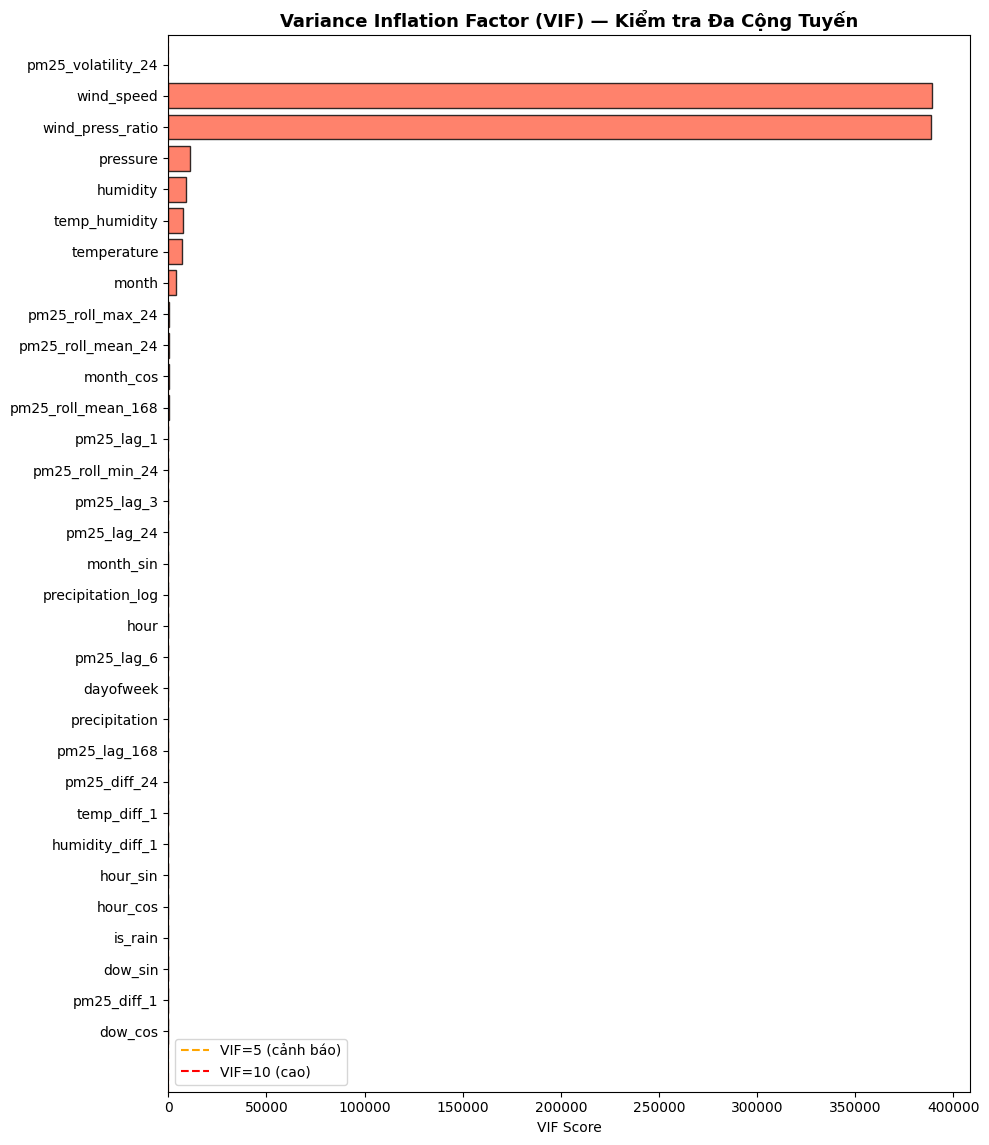


NHẬN XÉT VIF:
  Features VIF > 10 (22 features): ['pm25_roll_std_24', 'pm25_volatility_24', 'wind_speed', 'wind_press_ratio', 'pressure', 'humidity', 'temp_humidity', 'temperature', 'month', 'pm25_roll_max_24', 'pm25_roll_mean_24', 'month_cos', 'pm25_roll_mean_168', 'pm25_lag_1', 'pm25_roll_min_24', 'pm25_lag_3', 'pm25_lag_24', 'month_sin', 'precipitation_log', 'hour', 'pm25_lag_6', 'dayofweek']
  → Đây chủ yếu là lag features tự tương quan cao — bình thường với time series
  → Linear Regression: hệ số sẽ không ổn định cho các features này
  → Random Forest / XGBoost: không bị ảnh hưởng bởi VIF
  → Giải pháp: GIỮ tất cả features cho RF/XGBoost
               Interpret Linear Regression với thận trọng


In [2]:
# ══════════════════════════════════════════════════════════════════
# 10.1  TÍNH VIF CHO TẤT CẢ FEATURES
# ══════════════════════════════════════════════════════════════════
# Định nghĩa feature cols tạm thời để tính VIF (trước khi scale)
exclude_cols_temp = ['time','pm25','pm25_raw','pm25_interpolated','pm25_outlier_iqr','n_obs']
feature_cols_temp = [c for c in df_train.columns if c not in exclude_cols_temp]

# Lấy subset để tính nhanh (VIF có thể chậm với nhiều features)
X_vif = df_train[feature_cols_temp].dropna().head(5000)

print("Tính VIF cho tất cả features...")
print("(VIF > 10 = đa cộng tuyến cao; > 5 = cảnh báo)")

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF cho tất cả features:")
print(vif_data.to_string(index=False))

# ══════════════════════════════════════════════════════════════════
# 10.2  VISUALIZATION VIF
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, max(6, len(vif_data) * 0.35)))
colors = ['tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
          for v in vif_data['VIF']]
ax.barh(vif_data['feature'][::-1], vif_data['VIF'][::-1], color=colors[::-1], edgecolor='black', alpha=0.8)
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF=5 (cảnh báo)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF=10 (cao)')
ax.set_xlabel('VIF Score')
ax.set_title('Variance Inflation Factor (VIF) — Kiểm tra Đa Cộng Tuyến', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 10.3  NHẬN XÉT VÀ QUYẾT ĐỊNH
# ══════════════════════════════════════════════════════════════════
high_vif  = vif_data[vif_data['VIF'] > 10]
med_vif   = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]

print("\n" + "=" * 60)
print("NHẬN XÉT VIF:")
print("=" * 60)
if len(high_vif) > 0:
    print(f"  Features VIF > 10 ({len(high_vif)} features): {list(high_vif['feature'])}")
    print("  → Đây chủ yếu là lag features tự tương quan cao — bình thường với time series")
    print("  → Linear Regression: hệ số sẽ không ổn định cho các features này")
    print("  → Random Forest / XGBoost: không bị ảnh hưởng bởi VIF")
    print("  → Giải pháp: GIỮ tất cả features cho RF/XGBoost")
    print("               Interpret Linear Regression với thận trọng")
else:
    print("  Tất cả VIF <= 10 — đa cộng tuyến ở mức chấp nhận được")
print("=" * 60)


## 11. Scale Dữ Liệu (RobustScaler)

**Sau khi đã tạo xong tất cả features**, mới scale — đảm bảo lag/rolling features không bị encode thông tin từ scaler trước khi chúng được tính.


In [3]:
# ══════════════════════════════════════════════════════════════════
# 11.1  SCALE DỮ LIỆU
# FIT CHỈ TRÊN TRAIN, TRANSFORM VAL & TEST
# ══════════════════════════════════════════════════════════════════
weather_scale_cols = ['temperature','humidity','wind_speed','pressure','precipitation']
precip_log_cols    = ['precipitation_log']

weather_scaler    = RobustScaler()
precip_log_scaler = RobustScaler()
pm25_scaler       = RobustScaler()

df_train[weather_scale_cols] = weather_scaler.fit_transform(df_train[weather_scale_cols])
df_val[weather_scale_cols]   = weather_scaler.transform(df_val[weather_scale_cols])
df_test[weather_scale_cols]  = weather_scaler.transform(df_test[weather_scale_cols])

df_train[precip_log_cols] = precip_log_scaler.fit_transform(df_train[precip_log_cols])
df_val[precip_log_cols]   = precip_log_scaler.transform(df_val[precip_log_cols])
df_test[precip_log_cols]  = precip_log_scaler.transform(df_test[precip_log_cols])

# Scale target (pm25) — cần inverse sau khi predict
df_train[['pm25']] = pm25_scaler.fit_transform(df_train[['pm25']])
df_val[['pm25']]   = pm25_scaler.transform(df_val[['pm25']])
df_test[['pm25']]  = pm25_scaler.transform(df_test[['pm25']])


## 12. Chuẩn Bị Ma Trận X, y

Định nghĩa tập features sử dụng cho training (loại bỏ các cột meta, cột gốc chưa scale, và target).


In [4]:
# ══════════════════════════════════════════════════════════════════
# 12.1  ĐỊNH NGHĨA FEATURE COLUMNS
# ══════════════════════════════════════════════════════════════════
exclude_cols = [
    'time',
    'pm25',               # target (đã scale)
    'pm25_raw',           # giá trị gốc — chỉ dùng để tính lag
    'pm25_interpolated',
    'pm25_outlier_iqr',
    'n_obs',
]

feature_cols = [c for c in df_train.columns if c not in exclude_cols]
target_col   = 'pm25'

print(f"Target: '{target_col}'")
print(f"Số features: {len(feature_cols)}")
print(f"\nDanh sách features:")
for i, c in enumerate(feature_cols, 1):
    print(f"   {i:>2}. {c}")

# ══════════════════════════════════════════════════════════════════
# 12.2  TẠO X, y CHO TỪNG TẬP
# ══════════════════════════════════════════════════════════════════
X_train = df_train[feature_cols].copy()
y_train = df_train[target_col].copy()

X_val   = df_val[feature_cols].copy()
y_val   = df_val[target_col].copy()

X_test  = df_test[feature_cols].copy()
y_test  = df_test[target_col].copy()

print(f"\nKích thước:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

# Kiểm tra NaN
assert X_train.isna().sum().sum() == 0, "X_train còn NaN!"
assert X_val.isna().sum().sum()   == 0, "X_val còn NaN!"
assert X_test.isna().sum().sum()  == 0, "X_test còn NaN!"

all_metrics = []
all_preds   = {}


Target: 'pm25'
Số features: 33

Danh sách features:
    1. temperature
    2. humidity
    3. wind_speed
    4. pressure
    5. precipitation
    6. hour
    7. month
    8. dayofweek
    9. pm25_lag_1
   10. pm25_lag_3
   11. pm25_lag_6
   12. pm25_lag_24
   13. pm25_lag_168
   14. pm25_roll_mean_24
   15. pm25_roll_std_24
   16. pm25_roll_max_24
   17. pm25_roll_min_24
   18. pm25_roll_mean_168
   19. pm25_volatility_24
   20. pm25_diff_1
   21. pm25_diff_24
   22. precipitation_log
   23. is_rain
   24. hour_sin
   25. hour_cos
   26. month_sin
   27. month_cos
   28. dow_sin
   29. dow_cos
   30. temp_humidity
   31. wind_press_ratio
   32. temp_diff_1
   33. humidity_diff_1

Kích thước:
X_train: (4383, 33) | y_train: (4383,)
X_val  : (1248, 33)   | y_val  : (1248,)
X_test : (1521, 33)  | y_test : (1521,)


## 13. Baseline 1: Linear Regression

**Mục đích:** Baseline đơn giản nhất. Do đa cộng tuyến cao (VIF Section 10), hệ số không ổn định — nhưng kết quả dự báo vẫn dùng được làm tham chiếu.


In [5]:
# 13.1  TRAIN & PREDICT
print("Training Linear Regression...")
lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train, y_train)
print("Training hoàn tất!")

lr_val_pred,  lr_val_true  = predict_and_inverse(lr_model, X_val,  y_val,pm25_scaler)
lr_test_pred, lr_test_true = predict_and_inverse(lr_model, X_test, y_test, pm25_scaler)

all_preds['Linear Regression'] = {'val': lr_val_pred, 'test': lr_test_pred,
                                   'val_true': lr_val_true, 'test_true': lr_test_true}

m_val  = calculate_metrics(lr_val_true,  lr_val_pred,  "Validation", "Linear Regression")
m_test = calculate_metrics(lr_test_true, lr_test_pred, "Test",       "Linear Regression")
all_metrics.extend([m_val, m_test])

print("\nKẾT QUẢ LINEAR REGRESSION:")
print(pd.DataFrame([m_val, m_test]).to_string(index=False))

# 13.2  TOP COEFFICIENTS
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': lr_model.coef_.flatten()}) \
            .assign(abs_coef=lambda d: d['coefficient'].abs()) \
            .sort_values('abs_coef', ascending=False)
print("\nTop 10 hệ số lớn nhất:")
print(coef_df.head(10)[['feature','coefficient']].to_string(index=False))


Training Linear Regression...
Training hoàn tất!

=== Linear Regression - Validation ===
MAE      : 5.764 µg/m³
RMSE     : 9.800 µg/m³
R²       : 0.7440
MAPE     : 14.38%
Within±5 : 61.9%
Within±10: 84.7%

=== Linear Regression - Test ===
MAE      : 3.144 µg/m³
RMSE     : 4.944 µg/m³
R²       : 0.7713
MAPE     : 10.21%
Within±5 : 83.5%
Within±10: 97.0%

KẾT QUẢ LINEAR REGRESSION:
            Model    Dataset   MAE  RMSE     R²  MAPE (%)  Within±5 (%)  Within±10 (%)
Linear Regression Validation 5.764 9.800 0.7440     14.38          61.9           84.7
Linear Regression       Test 3.144 4.944 0.7713     10.21          83.5           97.0

Top 10 hệ số lớn nhất:
          feature  coefficient
 wind_press_ratio  2795.449507
       wind_speed   -14.233143
         humidity     0.364841
      temperature     0.128331
         hour_cos    -0.060753
        month_sin     0.053775
       pm25_lag_1     0.038235
         hour_sin     0.029387
precipitation_log    -0.023068
            month     

## 14. Baseline 2: Random Forest

**Mục đích:** Mô hình ensemble phi tuyến, không bị ảnh hưởng bởi đa cộng tuyến.


Training Random Forest (200 trees)...
Training hoàn tất!

=== Random Forest - Validation ===
MAE      : 6.148 µg/m³
RMSE     : 10.310 µg/m³
R²       : 0.7166
MAPE     : 17.02%
Within±5 : 58.8%
Within±10: 84.7%

=== Random Forest - Test ===
MAE      : 3.218 µg/m³
RMSE     : 4.999 µg/m³
R²       : 0.7662
MAPE     : 10.90%
Within±5 : 82.3%
Within±10: 96.5%

KẾT QUẢ RANDOM FOREST:
        Model    Dataset   MAE   RMSE     R²  MAPE (%)  Within±5 (%)  Within±10 (%)
Random Forest Validation 6.148 10.310 0.7166     17.02          58.8           84.7
Random Forest       Test 3.218  4.999 0.7662     10.90          82.3           96.5

Top 10 features (Random Forest):
          feature  importance
       pm25_lag_1    0.298352
     pm25_diff_24    0.124278
       pm25_lag_3    0.088766
      pm25_diff_1    0.069391
pm25_roll_mean_24    0.056569
 pm25_roll_max_24    0.044055
 pm25_roll_min_24    0.032489
      pm25_lag_24    0.029700
            month    0.023501
        month_cos    0.019907


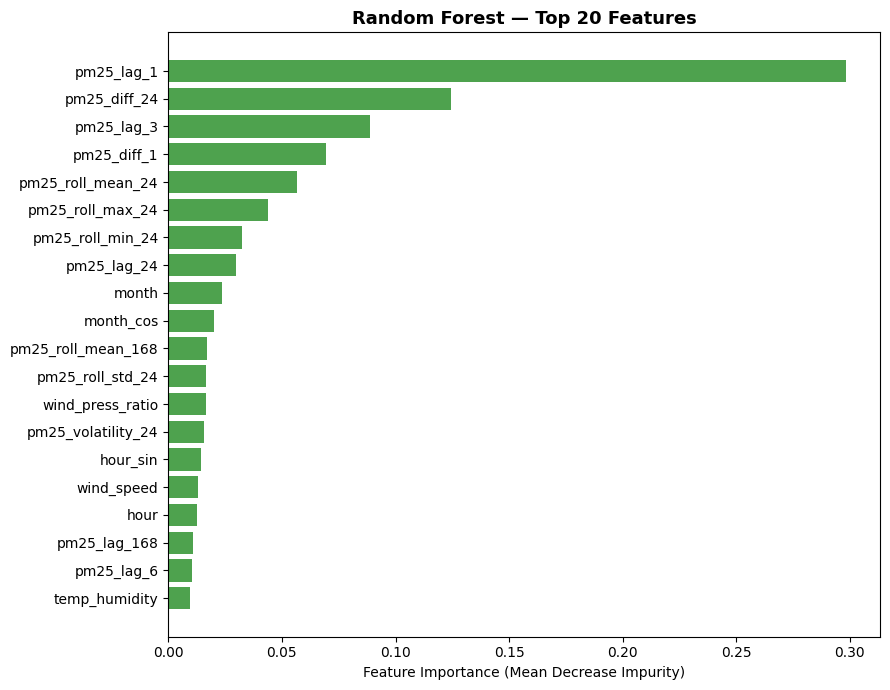

In [6]:
# 14.1  TRAIN
print("Training Random Forest (200 trees)...")
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_split=5,
    min_samples_leaf=3, max_features='sqrt', n_jobs=-1,
    random_state=42, verbose=0
)
rf_model.fit(X_train, np.ravel(y_train))
print("Training hoàn tất!")

# 14.2  PREDICT & METRICS
rf_val_pred,  rf_val_true  = predict_and_inverse(rf_model, X_val,  y_val, pm25_scaler)
rf_test_pred, rf_test_true = predict_and_inverse(rf_model, X_test, y_test, pm25_scaler)

all_preds['Random Forest'] = {'val': rf_val_pred, 'test': rf_test_pred,
                               'val_true': rf_val_true, 'test_true': rf_test_true}

m_val  = calculate_metrics(rf_val_true,  rf_val_pred,  "Validation", "Random Forest")
m_test = calculate_metrics(rf_test_true, rf_test_pred, "Test",       "Random Forest")
all_metrics.extend([m_val, m_test])

print("\nKẾT QUẢ RANDOM FOREST:")
print(pd.DataFrame([m_val, m_test]).to_string(index=False))

# 14.3  FEATURE IMPORTANCE
rf_imp = pd.DataFrame({'feature': feature_cols,
                        'importance': rf_model.feature_importances_}) \
            .sort_values('importance', ascending=False)
print("\nTop 10 features (Random Forest):")
print(rf_imp.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
rf_plot = rf_imp.head(20).sort_values('importance', ascending=True)
ax.barh(rf_plot['feature'], rf_plot['importance'], color='forestgreen', alpha=0.8)
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title('Random Forest — Top 20 Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 15. Baseline 3: XGBoost với Time Series Cross-Validation

**Chiến lược:** 5-fold TimeSeriesSplit để đánh giá ổn định, sau đó train final model với early stopping trên Val.


Time Series Cross-Validation (5-fold)...
   Fold 1: R² = 0.4938
   Fold 2: R² = 0.6537
   Fold 3: R² = 0.5218
   Fold 4: R² = 0.6968
   Fold 5: R² = 0.5126

CV Result: Mean R² = 0.5757 ± 0.0829

Training final XGBoost model...
[0]	validation_0-rmse:1.03876
[20]	validation_0-rmse:0.67921
[40]	validation_0-rmse:0.58661
[60]	validation_0-rmse:0.56662
[80]	validation_0-rmse:0.56015
[100]	validation_0-rmse:0.56064
[120]	validation_0-rmse:0.56192
[137]	validation_0-rmse:0.56343
Training hoàn tất! Best iteration: 87

=== XGBoost - Validation ===
MAE      : 5.878 µg/m³
RMSE     : 10.608 µg/m³
R²       : 0.7000
MAPE     : 14.72%
Within±5 : 64.7%
Within±10: 84.6%

=== XGBoost - Test ===
MAE      : 3.027 µg/m³
RMSE     : 4.811 µg/m³
R²       : 0.7835
MAPE     : 10.04%
Within±5 : 83.2%
Within±10: 97.1%

KẾT QUẢ XGBOOST:
  Model    Dataset   MAE   RMSE     R²  MAPE (%)  Within±5 (%)  Within±10 (%)
XGBoost Validation 5.878 10.608 0.7000     14.72          64.7           84.6
XGBoost       Test 3.027

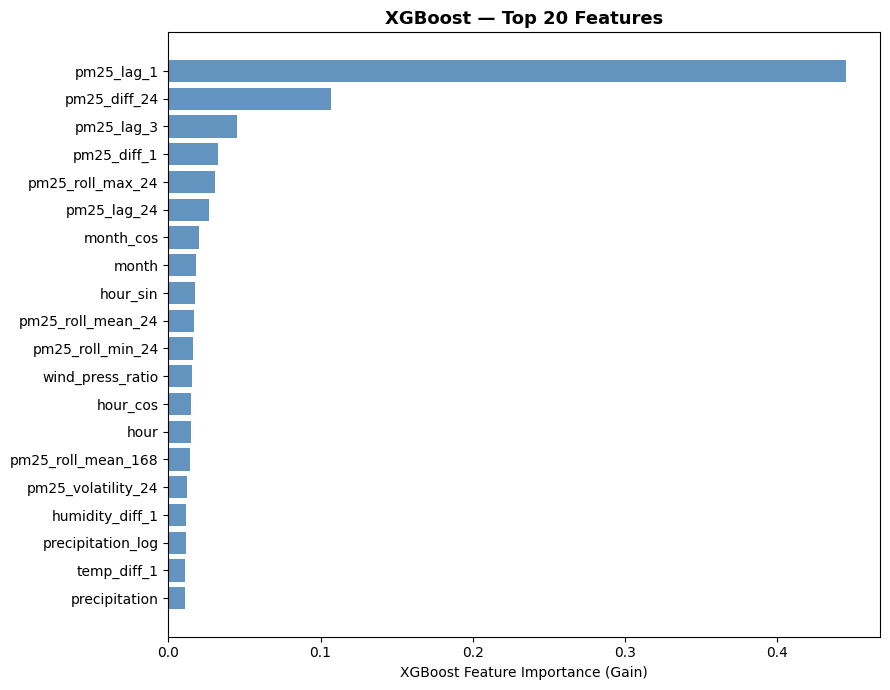

In [ ]:
# 15.1  TIME SERIES CROSS-VALIDATION
print("Time Series Cross-Validation (5-fold)...")
tscv      = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train), 1):
    X_tr_f, X_vl_f = X_train.iloc[tr_idx], X_train.iloc[vl_idx]
    y_tr_f, y_vl_f = y_train.iloc[tr_idx], y_train.iloc[vl_idx]
    m_fold = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbosity=0
    )
    m_fold.fit(X_tr_f, np.ravel(y_tr_f))
    r2 = r2_score(np.ravel(y_vl_f), m_fold.predict(X_vl_f))
    cv_scores.append(r2)
    print(f"   Fold {fold}: R² = {r2:.4f}")

print(f"\nCV Result: Mean R² = {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# 15.2  TRAIN FINAL MODEL
print("\nTraining final XGBoost model...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=7, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85, colsample_bylevel=0.9,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    n_jobs=-1, verbosity=0, early_stopping_rounds=50, eval_metric='rmse'
)
xgb_model.fit(
    X_train, np.ravel(y_train),
    eval_set=[(X_val, np.ravel(y_val))],
    verbose=20
)
print(f"Training hoàn tất! Best iteration: {xgb_model.best_iteration}")

# 15.3  PREDICT & METRICS
xgb_val_pred,  xgb_val_true  = predict_and_inverse(xgb_model, X_val,  y_val, pm25_scaler)
xgb_test_pred, xgb_test_true = predict_and_inverse(xgb_model, X_test, y_test, pm25_scaler)

all_preds['XGBoost'] = {'val': xgb_val_pred, 'test': xgb_test_pred,
                         'val_true': xgb_val_true, 'test_true': xgb_test_true}

m_val  = calculate_metrics(xgb_val_true,  xgb_val_pred,  "Validation", "XGBoost")
m_test = calculate_metrics(xgb_test_true, xgb_test_pred, "Test",       "XGBoost")
all_metrics.extend([m_val, m_test])

print("\nKẾT QUẢ XGBOOST:")
print(pd.DataFrame([m_val, m_test]).to_string(index=False))

# 15.4  FEATURE IMPORTANCE
xgb_imp = pd.DataFrame({'feature': feature_cols,
                         'importance': xgb_model.feature_importances_}) \
            .sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
xgb_plot = xgb_imp.head(20).sort_values('importance', ascending=True)
ax.barh(xgb_plot['feature'], xgb_plot['importance'], color='steelblue', alpha=0.85)
ax.set_xlabel('XGBoost Feature Importance (Gain)')
ax.set_title('XGBoost — Top 20 Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 16. Residual Analysis

**Tại sao cần phân tích residual?**

Residual analysis kiểm tra xem model có học được tất cả pattern trong dữ liệu không:
- **Residual random** → model đã capture hết cấu trúc
- **Residual có pattern** (heteroscedasticity, autocorrelation) → còn signal chưa được model hóa
- **Quantile-Quantile plot** → kiểm tra phân phối residual

Kết quả này cũng là **feedback cho phần tiền xử lý**: nếu residual có autocorrelation → cần thêm lag features.


Residual Statistics (XGBoost, Test Set):
  Mean   : 0.3015 µg/m³  (gần 0 = unbiased)
  Std    : 4.8015 µg/m³
  Min    : -29.8204 µg/m³
  Max    : 80.1975 µg/m³
  Skew   : 3.2402  (gần 0 = symmetric)
  Kurtosis: 54.8148  (gần 0 = normal)


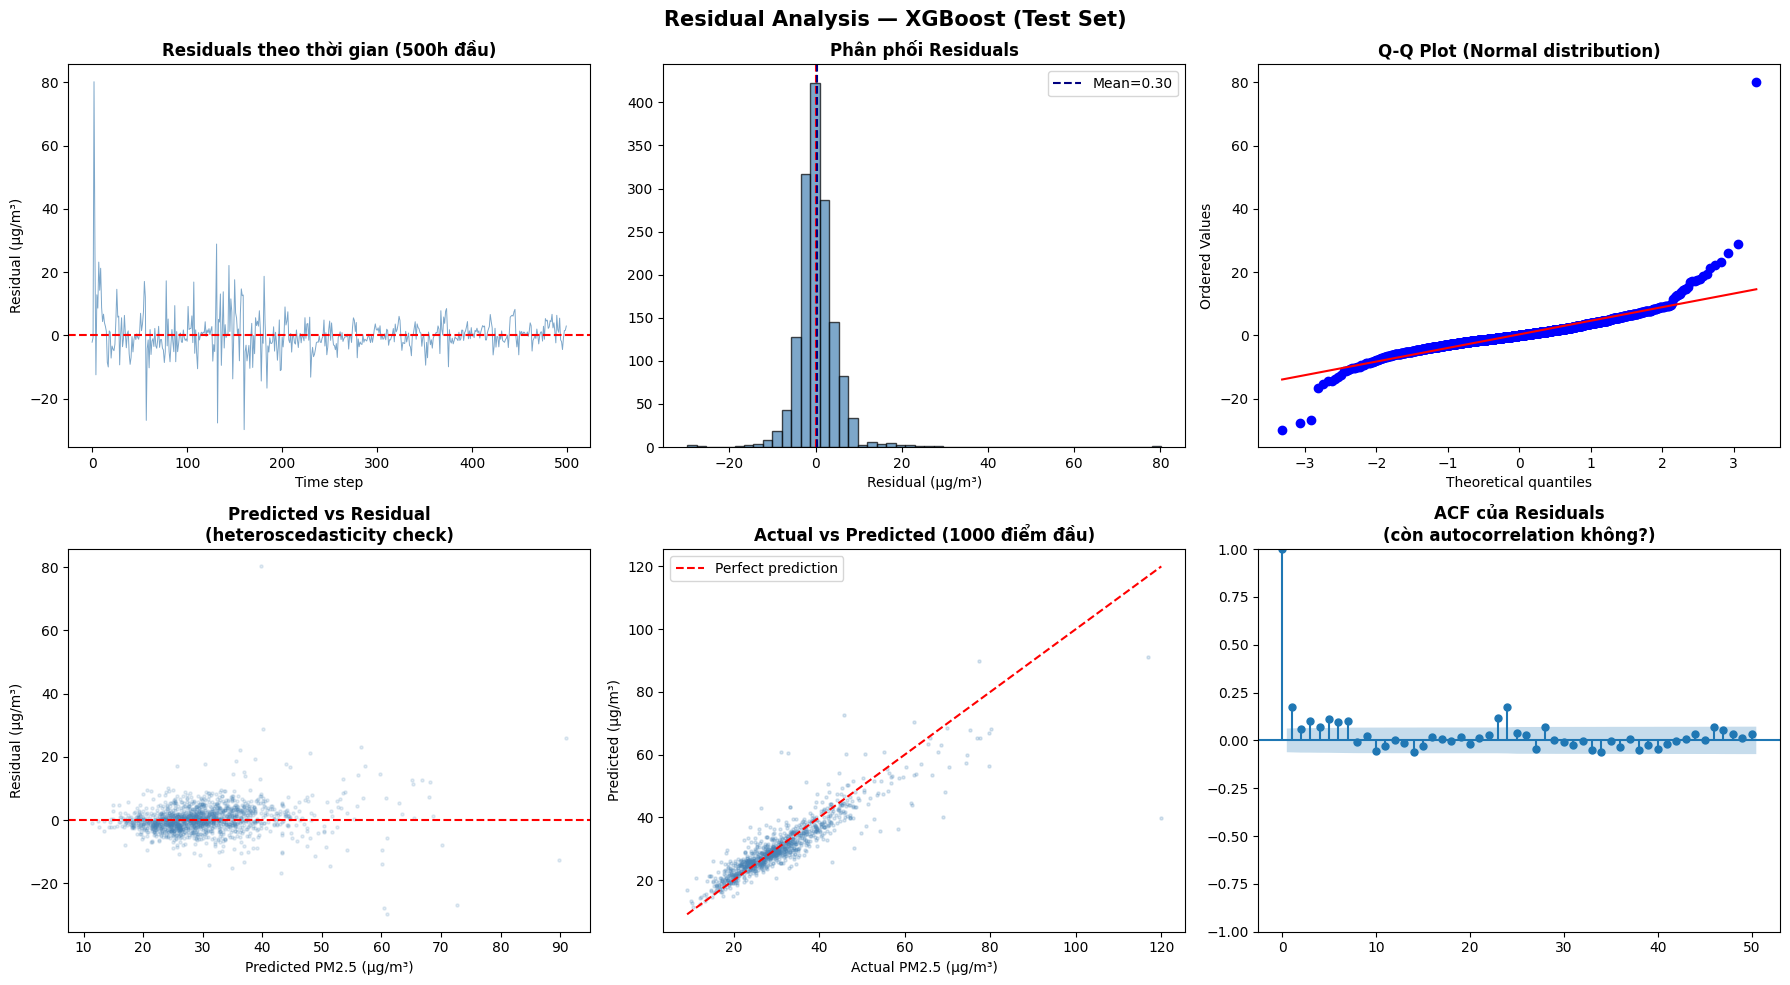


Shapiro-Wilk Test (500 residuals đầu):
  Statistic: 0.7498
  p-value  : 0.000000
  → Residuals không phân phối chuẩn (bình thường cho time series)


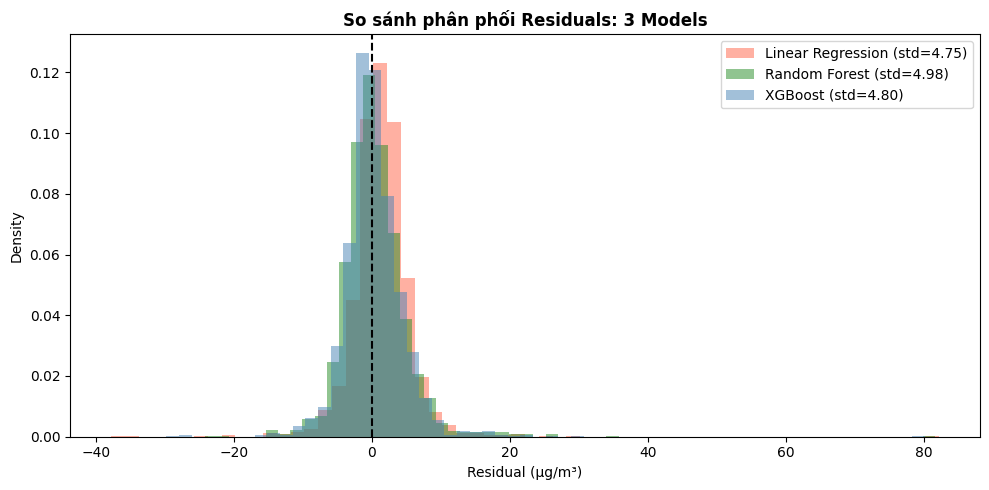

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 16.1  TÍNH RESIDUALS (TEST SET — BEST MODEL = XGBOOST)
# ══════════════════════════════════════════════════════════════════
y_true_res = all_preds['XGBoost']['test_true']
y_pred_res = all_preds['XGBoost']['test']
residuals  = y_true_res - y_pred_res

print("Residual Statistics (XGBoost, Test Set):")
print(f"  Mean   : {residuals.mean():.4f} µg/m³  (gần 0 = unbiased)")
print(f"  Std    : {residuals.std():.4f} µg/m³")
print(f"  Min    : {residuals.min():.4f} µg/m³")
print(f"  Max    : {residuals.max():.4f} µg/m³")
print(f"  Skew   : {pd.Series(residuals).skew():.4f}  (gần 0 = symmetric)")
print(f"  Kurtosis: {pd.Series(residuals).kurtosis():.4f}  (gần 0 = normal)")

# ══════════════════════════════════════════════════════════════════
# 16.2  VISUALIZATION
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residual Analysis — XGBoost (Test Set)', fontsize=15, fontweight='bold')

# Plot 1: Residual over time
axes[0, 0].plot(residuals[:500], color='steelblue', alpha=0.7, linewidth=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('Residuals theo thời gian (500h đầu)', fontweight='bold')
axes[0, 0].set_xlabel('Time step'); axes[0, 0].set_ylabel('Residual (µg/m³)')

# Plot 2: Residual distribution
axes[0, 1].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].axvline(residuals.mean(), color='navy', linestyle='--', linewidth=1.5,
                    label=f'Mean={residuals.mean():.2f}')
axes[0, 1].set_title('Phân phối Residuals', fontweight='bold')
axes[0, 1].set_xlabel('Residual (µg/m³)'); axes[0, 1].legend()

# Plot 3: Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Normal distribution)', fontweight='bold')

# Plot 4: Predicted vs Residual (Heteroscedasticity check)
axes[1, 0].scatter(y_pred_res, residuals, alpha=0.15, s=5, color='steelblue')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Predicted vs Residual\n(heteroscedasticity check)', fontweight='bold')
axes[1, 0].set_xlabel('Predicted PM2.5 (µg/m³)')
axes[1, 0].set_ylabel('Residual (µg/m³)')

# Plot 5: Actual vs Predicted (scatter)
axes[1, 1].scatter(y_true_res[:1000], y_pred_res[:1000], alpha=0.2, s=5, color='steelblue')
lim = [min(y_true_res.min(), y_pred_res.min()), max(y_true_res.max(), y_pred_res.max())]
axes[1, 1].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_title('Actual vs Predicted (1000 điểm đầu)', fontweight='bold')
axes[1, 1].set_xlabel('Actual PM2.5 (µg/m³)'); axes[1, 1].set_ylabel('Predicted (µg/m³)')
axes[1, 1].legend()

# Plot 6: ACF of residuals (autocorrelation check)
plot_acf(residuals[:1000], lags=50, ax=axes[1, 2], alpha=0.05)
axes[1, 2].set_title('ACF của Residuals\n(còn autocorrelation không?)', fontweight='bold')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 16.3  NORMALITY TEST (Shapiro-Wilk trên subset)
# ══════════════════════════════════════════════════════════════════
sample_res = residuals[:500]
shapiro_stat, shapiro_pval = stats.shapiro(sample_res)
print(f"\nShapiro-Wilk Test (500 residuals đầu):")
print(f"  Statistic: {shapiro_stat:.4f}")
print(f"  p-value  : {shapiro_pval:.6f}")
if shapiro_pval < 0.05:
    print("  → Residuals không phân phối chuẩn (bình thường cho time series)")
else:
    print("  → Residuals gần phân phối chuẩn")

# ══════════════════════════════════════════════════════════════════
# 16.4  COMPARE RESIDUALS ALL MODELS
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
for name, color in [('Linear Regression','tomato'), ('Random Forest','forestgreen'), ('XGBoost','steelblue')]:
    if name in all_preds:
        res = all_preds[name]['test_true'] - all_preds[name]['test']
        ax.hist(res, bins=60, alpha=0.5, color=color, label=f'{name} (std={res.std():.2f})', density=True)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual (µg/m³)'); ax.set_ylabel('Density')
ax.set_title('So sánh phân phối Residuals: 3 Models', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 17. So Sánh Tổng Hợp + Statistical Significance Tests


SO SÁNH CÁC MODELS — TEST SET (sắp xếp theo RMSE)
            Model Dataset   MAE  RMSE     R²  MAPE (%)  Within±5 (%)  Within±10 (%)
          XGBoost    Test 3.027 4.811 0.7835     10.04          83.2           97.1
Linear Regression    Test 3.144 4.944 0.7713     10.21          83.5           97.0
    Random Forest    Test 3.218 4.999 0.7662     10.90          82.3           96.5


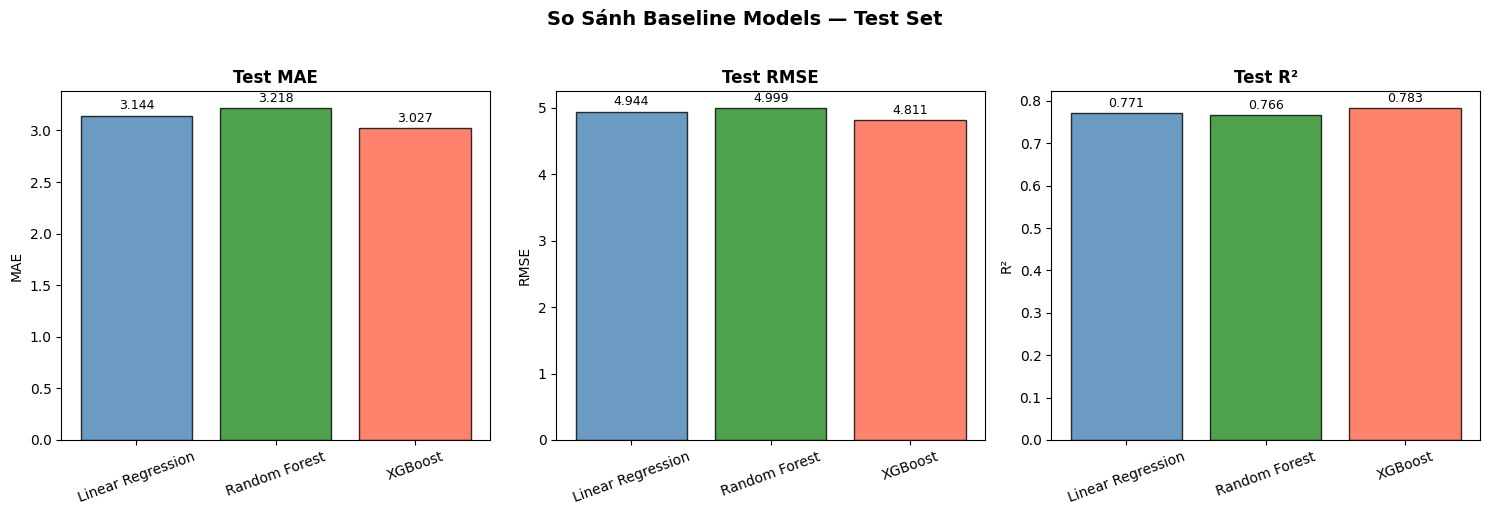


DIEBOLD-MARIANO TEST (h=1, alpha=0.05)
  XGBoost vs Random Forest:
    DM=-2.2666, p=0.0234 → SIGNIFICANT (p=0.0234) — XGBoost tốt hơn
  XGBoost vs Linear Regression:
    DM=-1.4023, p=0.1608 → not significant (p=0.1608)
  Random Forest vs Linear Regression:
    DM=0.4048, p=0.6856 → not significant (p=0.6856)

PAIRED T-TEST (alpha=0.05)
  XGBoost vs Random Forest:
    t=-4.6199, p=0.0000 → SIGNIFICANT (p=0.0000) — XGBoost tốt hơn
  XGBoost vs Linear Regression:
    t=-2.0062, p=0.0450 → SIGNIFICANT (p=0.0450) — XGBoost tốt hơn
  Random Forest vs Linear Regression:
    t=1.1231, p=0.2616 → not significant (p=0.2616)


In [9]:
# ══════════════════════════════════════════════════════════════════
# 17.1  BẢNG SO SÁNH TỔNG HỢP
# ══════════════════════════════════════════════════════════════════
metrics_df = pd.DataFrame(all_metrics)
test_metrics = metrics_df[metrics_df['Dataset'] == 'Test'].sort_values('RMSE').reset_index(drop=True)

print("=" * 80)
print("SO SÁNH CÁC MODELS — TEST SET (sắp xếp theo RMSE)")
print("=" * 80)
print(test_metrics.to_string(index=False))
print("=" * 80)

# Visualization: bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_to_plot = ['MAE', 'RMSE', 'R²']
colors = ['steelblue','forestgreen','tomato']

for ax, metric in zip(axes, metrics_to_plot):
    test_m = metrics_df[metrics_df['Dataset'] == 'Test']
    bars   = ax.bar(test_m['Model'], test_m[metric], color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(f'Test {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, test_m[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('So Sánh Baseline Models — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 17.2  DIEBOLD-MARIANO TEST
# ══════════════════════════════════════════════════════════════════
def diebold_mariano_test(y_true, y_pred1, y_pred2, name1, name2, h=1):
    d    = (y_true - y_pred1)**2 - (y_true - y_pred2)**2
    n    = len(d)
    mean_d = d.mean()
    var_d  = d.var(ddof=1)
    for lag in range(1, min(h, n//3)):
        cov = np.cov(d[:-lag], d[lag:])[0,1]
        var_d += 2 * cov
    dm_stat = mean_d / np.sqrt(var_d / n)
    pval    = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    winner  = name1 if mean_d < 0 else name2
    sig     = f"SIGNIFICANT (p={pval:.4f}) — {winner} tốt hơn" if pval < 0.05 else f"not significant (p={pval:.4f})"
    return dm_stat, pval, sig

print("\n" + "=" * 70)
print("DIEBOLD-MARIANO TEST (h=1, alpha=0.05)")
print("=" * 70)

pairs = [('XGBoost','Random Forest'), ('XGBoost','Linear Regression'), ('Random Forest','Linear Regression')]
dm_results = []
for m1, m2 in pairs:
    if m1 in all_preds and m2 in all_preds:
        yt  = all_preds[m1]['test_true']
        yp1 = all_preds[m1]['test']
        yp2 = all_preds[m2]['test']
        n   = min(len(yt), len(yp1), len(yp2))
        dm_stat, pval, sig = diebold_mariano_test(yt[:n], yp1[:n], yp2[:n], m1, m2)
        dm_results.append({'Comparison': f'{m1} vs {m2}', 'DM Stat': round(dm_stat,4),
                           'p-value': round(pval,4), 'Conclusion': sig})
        print(f"  {m1} vs {m2}:")
        print(f"    DM={dm_stat:.4f}, p={pval:.4f} → {sig}")

# ══════════════════════════════════════════════════════════════════
# 17.3  PAIRED T-TEST
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PAIRED T-TEST (alpha=0.05)")
print("=" * 70)

ttest_results = []
for m1, m2 in pairs:
    if m1 in all_preds and m2 in all_preds:
        yt   = all_preds[m1]['test_true']
        yp1  = all_preds[m1]['test']
        yp2  = all_preds[m2]['test']
        n    = min(len(yt), len(yp1), len(yp2))
        e1   = np.abs(yt[:n] - yp1[:n])
        e2   = np.abs(yt[:n] - yp2[:n])
        t, p = stats.ttest_rel(e1, e2)
        winner = m1 if e1.mean() < e2.mean() else m2
        sig    = f"SIGNIFICANT (p={p:.4f}) — {winner} tốt hơn" if p < 0.05 else f"not significant (p={p:.4f})"
        ttest_results.append({'Comparison': f'{m1} vs {m2}', 't-stat': round(t,4),
                              'p-value': round(p,4), 'Conclusion': sig})
        print(f"  {m1} vs {m2}:")
        print(f"    t={t:.4f}, p={p:.4f} → {sig}")
